In [1]:
from datasets import load_dataset

ds = load_dataset("changelinglab/easycall-dysarthria")

In [2]:
severity1 = ds["train"].filter(
    lambda x: x["dysarthria_severity"] == "1"
)

In [3]:
print(len(severity1))

3588


In [4]:
from collections import Counter

commands = Counter(severity1["text"])

print("Unique commands:", len(commands))
print(commands)

Unique commands: 71
Counter({'uno': 53, 'rubrica': 53, 'rimuovi': 53, 'vai nel registro chiamate': 53, 'salva': 53, 'chiudi rubrica': 53, 'si': 53, 'nave': 53, 'muovi': 53, 'chiama ultimo numero': 53, 'sei': 53, 'apri': 53, 'sotto': 53, 'aggiungi ai preferiti': 53, 'zelo': 53, 'scendi': 53, 'vai alla tastiera': 53, 'disattiva vivavoce': 53, 'raggiungi': 53, 'tra': 53, 'chiudi applicazione': 53, 'bue': 53, 'cancella tutto': 53, 'termina chiamata': 53, 'aggiungi': 53, 'scorri verso il basso': 53, 'quattro': 53, 'cancella contatto': 53, 'no': 53, 'nove': 53, 'seleziona': 53, 'richiama': 53, 'fai una telefonata': 53, 'deseleziona': 53, 'chiama': 53, 'sopra': 53, 'sette': 53, 'nuovo contatto': 53, 'chiudi': 53, 'vai alla pagina principale': 53, 'zero': 53, 'stop': 53, 'due': 53, 'vivavoce': 53, 'tre': 53, 'cinque': 53, 'scesi': 53, 'cancella': 53, 'chiama emergenza': 53, 'preferiti': 53, 'sali': 53, 'top': 53, 'indietro': 53, 'otto': 53, 'attiva vivavoce': 53, 'muto': 53, 'terminare': 53, '

In [5]:
import whisper
import torch

model = whisper.load_model("turbo")

print("Model loaded")

Model loaded


In [9]:
from collections import defaultdict

command_samples = defaultdict(list)

for sample in severity1:
    command = sample["text"]
    command_samples[command].append(sample)

print("Commands collected:", len(command_samples))

Commands collected: 71


In [11]:
from collections import defaultdict
import re
import numpy as np

command_transcripts = defaultdict(list)

for command, samples in command_samples.items():

    for sample in samples:

        audio = sample["audio"]["array"].astype(np.float32)

        result = model.transcribe(
            audio,
            language="it",
            task="transcribe"
        )

        pred = result["text"].lower().strip()

        # normalize
        pred = re.sub(r"[^\w\s]", "", pred)

        command_transcripts[command].append(pred)

print("ASR inference completed.")

ASR inference completed.


In [12]:
cmd = "rubrica"

for t in command_transcripts[cmd][:15]:
    print(t)

grazie
buon appetito
rubrica
allo пробuja
dovevo bell
rubrica
no baby
appreciated riscendo
a300
ruggite
buon appetito
있다
оду lambéza
rocka rija용bolo
alla bonita


consistency = frequency of most common transcript / total samples

In [13]:
from collections import Counter

command_consistency = {}

for command, transcripts in command_transcripts.items():

    counts = Counter(transcripts)

    top_transcript, top_count = counts.most_common(1)[0]

    score = top_count / len(transcripts)

    command_consistency[command] = {
        "score": score,
        "top_transcript": top_transcript,
        "top_count": top_count,
        "total": len(transcripts)
    }

In [14]:
sorted_commands = sorted(
    command_consistency.items(),
    key=lambda x: x[1]["score"],
    reverse=True
)

for cmd, info in sorted_commands[:20]:
    print(cmd, "->", info)

cella -> {'score': 0.6415094339622641, 'top_transcript': 'ciao', 'top_count': 34, 'total': 53}
salva -> {'score': 0.6037735849056604, 'top_transcript': 'ciao', 'top_count': 32, 'total': 53}
sali -> {'score': 0.5849056603773585, 'top_transcript': 'ciao', 'top_count': 31, 'total': 53}
sei -> {'score': 0.49056603773584906, 'top_transcript': 'ciao', 'top_count': 26, 'total': 53}
no -> {'score': 0.4339622641509434, 'top_transcript': 'no', 'top_count': 23, 'total': 53}
fai una telefonata -> {'score': 0.32075471698113206, 'top_transcript': 'grazie a tutti', 'top_count': 17, 'total': 53}
si -> {'score': 0.3018867924528302, 'top_transcript': 'oh', 'top_count': 16, 'total': 53}
nove -> {'score': 0.3018867924528302, 'top_transcript': 'noi', 'top_count': 16, 'total': 53}
tre -> {'score': 0.3018867924528302, 'top_transcript': 'ah', 'top_count': 16, 'total': 53}
chiama -> {'score': 0.2830188679245283, 'top_transcript': 'ciao', 'top_count': 15, 'total': 53}
cinque -> {'score': 0.2641509433962264, 'to

In [15]:
import pandas as pd

rows = []

for cmd, info in command_consistency.items():

    rows.append({
        "command": cmd,
        "consistency": info["score"],
        "top_transcript": info["top_transcript"],
        "samples": info["total"]
    })

df = pd.DataFrame(rows)

df = df.sort_values("consistency", ascending=False)

df.head(20)

,command,consistency,top_transcript,samples
65,cella,0.641509,ciao,53
4,salva,0.603774,ciao,53
52,sali,0.584906,ciao,53
10,sei,0.490566,ciao,53
30,no,0.433962,no,53
34,fai una telefonata,0.320755,grazie a tutti,53
6,si,0.301887,oh,53
31,nove,0.301887,noi,53
46,tre,0.301887,ah,53
36,chiama,0.283019,ciao,53


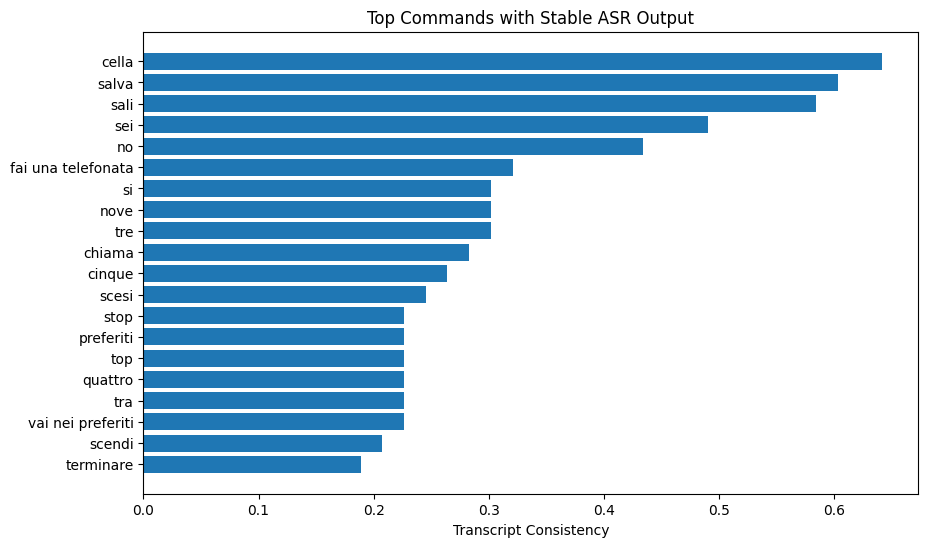

In [16]:
import matplotlib.pyplot as plt

top_df = df.head(20)

plt.figure(figsize=(10,6))

plt.barh(top_df["command"], top_df["consistency"])

plt.xlabel("Transcript Consistency")
plt.title("Top Commands with Stable ASR Output")

plt.gca().invert_yaxis()

plt.show()

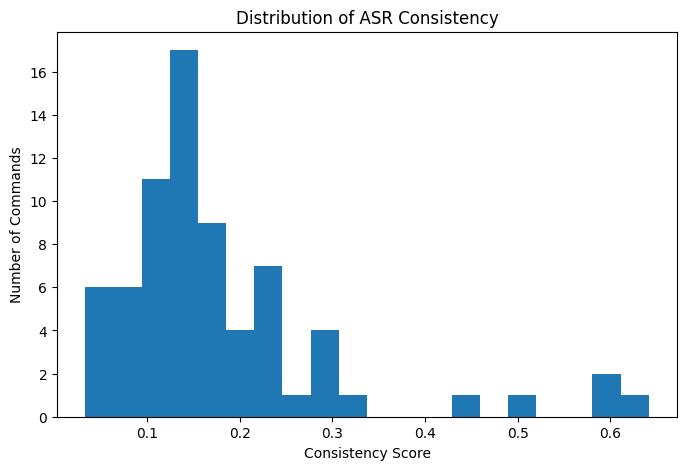

In [17]:
plt.figure(figsize=(8,5))

plt.hist(df["consistency"], bins=20)

plt.xlabel("Consistency Score")
plt.ylabel("Number of Commands")

plt.title("Distribution of ASR Consistency")

plt.show()

In [18]:
mvp_commands = df[df["consistency"] >= 0.30]

print("MVP command candidates:", len(mvp_commands))

mvp_commands

MVP command candidates: 9


,command,consistency,top_transcript,samples
65,cella,0.641509,ciao,53
4,salva,0.603774,ciao,53
52,sali,0.584906,ciao,53
10,sei,0.490566,ciao,53
30,no,0.433962,no,53
34,fai una telefonata,0.320755,grazie a tutti,53
6,si,0.301887,oh,53
31,nove,0.301887,noi,53
46,tre,0.301887,ah,53


In [19]:
cmd = mvp_commands.iloc[0]["command"]

print("Command:", cmd)

Counter(command_transcripts[cmd]).most_common(10)

Command: cella


[('ciao', 34),
 ('a', 2),
 ('grazie a tutti', 2),
 ('sotto', 1),
 ('voila', 1),
 ('tbau', 1),
 ('oh', 1),
 ('ciao no', 1),
 ('he esperت', 1),
 ('еспritte', 1)]

In [20]:
import math
from collections import Counter

command_entropy = {}

for command, transcripts in command_transcripts.items():

    counts = Counter(transcripts)
    total = len(transcripts)

    entropy = 0

    for c in counts.values():
        p = c / total
        entropy -= p * math.log2(p)

    command_entropy[command] = entropy

In [21]:
df["entropy"] = df["command"].map(command_entropy)

df = df.sort_values(["consistency","entropy"], ascending=[False, True])

df.head(20)

,command,consistency,top_transcript,samples,entropy
65,cella,0.641509,ciao,53,2.388793
4,salva,0.603774,ciao,53,2.482637
52,sali,0.584906,ciao,53,2.627261
10,sei,0.490566,ciao,53,2.896114
30,no,0.433962,no,53,2.911671
34,fai una telefonata,0.320755,grazie a tutti,53,4.341376
6,si,0.301887,oh,53,3.072168
46,tre,0.301887,ah,53,3.398035
31,nove,0.301887,noi,53,3.894689
36,chiama,0.283019,ciao,53,4.244838


In [22]:
from collections import Counter

all_transcripts = []

for t in command_transcripts.values():
    all_transcripts.extend(t)

Counter(all_transcripts).most_common(20)

[('ciao', 300),
 ('grazie', 278),
 ('grazie a tutti', 267),
 ('no', 65),
 ('oh', 63),
 ('noi', 48),
 ('sì', 40),
 ('ciao a tutti', 39),
 ('ok', 30),
 ('ah', 30),
 ('a', 27),
 ('ciao ciao', 25),
 ('allora', 21),
 ('', 20),
 ('a presto', 19),
 ('stop', 18),
 ('quattro', 15),
 ('papa', 14),
 ('4', 14),
 ('buon appetito', 11)]

In [23]:
for cmd, info in sorted_commands[:10]:
    print("\nCOMMAND:", cmd)
    print(Counter(command_transcripts[cmd]).most_common(5))


COMMAND: cella
[('ciao', 34), ('a', 2), ('grazie a tutti', 2), ('sotto', 1), ('voila', 1)]

COMMAND: salva
[('ciao', 32), ('ciao a tutti', 4), ('grazie', 2), ('bye bye', 2), ('sido le', 1)]

COMMAND: sali
[('ciao', 31), ('sali', 3), ('sì', 2), ('grazie a tutti', 2), ('fai', 2)]

COMMAND: sei
[('ciao', 26), ('hai', 5), ('sì', 3), ('oh', 3), ('ok', 3)]

COMMAND: no
[('no', 23), ('grazie', 10), ('ciao', 4), ('la', 2), ('grazie a tutti', 2)]

COMMAND: fai una telefonata
[('grazie a tutti', 17), ('ciao a tutti', 2), ('grazie per la visione', 2), ('fai un teleponata', 1), ('vai notari prata', 1)]

COMMAND: si
[('oh', 16), ('grazie', 8), ('sì', 8), ('ho', 8), ('ciao', 3)]

COMMAND: nove
[('noi', 16), ('ciao', 7), ('grazie', 3), ('no', 3), ('ciao a tutti', 2)]

COMMAND: tre
[('ah', 16), ('oh', 10), ('grazie', 6), ('ciao', 3), ('buongiorno', 2)]

COMMAND: chiama
[('ciao', 15), ('chiama', 4), ('grazie', 4), ('buongiorno', 2), ('grazie a tutti', 2)]


In [25]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [26]:
import numpy as np

command_embeddings = {}

for command, transcripts in command_transcripts.items():

    emb = embedder.encode(transcripts)

    command_embeddings[command] = emb

In [27]:
command_centroids = {}

for cmd, emb in command_embeddings.items():

    centroid = np.mean(emb, axis=0)

    command_centroids[cmd] = centroid

In [28]:
from sklearn.metrics.pairwise import cosine_similarity

separability_scores = {}

for cmd1, c1 in command_centroids.items():

    similarities = []

    for cmd2, c2 in command_centroids.items():

        if cmd1 == cmd2:
            continue

        sim = cosine_similarity([c1],[c2])[0][0]
        similarities.append(sim)

    separability_scores[cmd1] = 1 - max(similarities)

In [29]:
df["separability"] = df["command"].map(separability_scores)

df["final_score"] = (
    df["consistency"]
    * df["separability"]
    / (df["entropy"] + 1e-5)
)

df = df.sort_values("final_score", ascending=False)

df.head(20)

,command,consistency,top_transcript,samples,entropy,separability,final_score
30,no,0.433962,no,53,2.911671,0.056321,0.008394
28,quattro,0.226415,4,53,3.167496,0.074133,0.005299
29,cancella contatto,0.188679,grazie a tutti,53,4.860483,0.075764,0.002941
43,stop,0.226415,stop,53,3.535605,0.045560,0.002918
10,sei,0.490566,ciao,53,2.896114,0.015359,0.002602
34,fai una telefonata,0.320755,grazie a tutti,53,4.341376,0.032152,0.002375
39,nuovo contatto,0.132075,nuovo contatto,53,4.852329,0.075764,0.002062
62,sezione,0.169811,grazie a tutti,53,4.653662,0.056396,0.002058
31,nove,0.301887,noi,53,3.894689,0.026214,0.002032
4,salva,0.603774,ciao,53,2.482637,0.006830,0.001661


In [30]:
top_commands = df.head(10)

top_commands

,command,consistency,top_transcript,samples,entropy,separability,final_score
30,no,0.433962,no,53,2.911671,0.056321,0.008394
28,quattro,0.226415,4,53,3.167496,0.074133,0.005299
29,cancella contatto,0.188679,grazie a tutti,53,4.860483,0.075764,0.002941
43,stop,0.226415,stop,53,3.535605,0.045560,0.002918
10,sei,0.490566,ciao,53,2.896114,0.015359,0.002602
34,fai una telefonata,0.320755,grazie a tutti,53,4.341376,0.032152,0.002375
39,nuovo contatto,0.132075,nuovo contatto,53,4.852329,0.075764,0.002062
62,sezione,0.169811,grazie a tutti,53,4.653662,0.056396,0.002058
31,nove,0.301887,noi,53,3.894689,0.026214,0.002032
4,salva,0.603774,ciao,53,2.482637,0.006830,0.001661


In [32]:
import umap
import matplotlib.pyplot as plt

In [33]:
all_emb = []
labels = []

for cmd, emb in command_embeddings.items():

    all_emb.extend(emb)
    labels.extend([cmd]*len(emb))

In [34]:
reducer = umap.UMAP()

emb2d = reducer.fit_transform(all_emb)

/mnt/f/Speak/speak_env/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


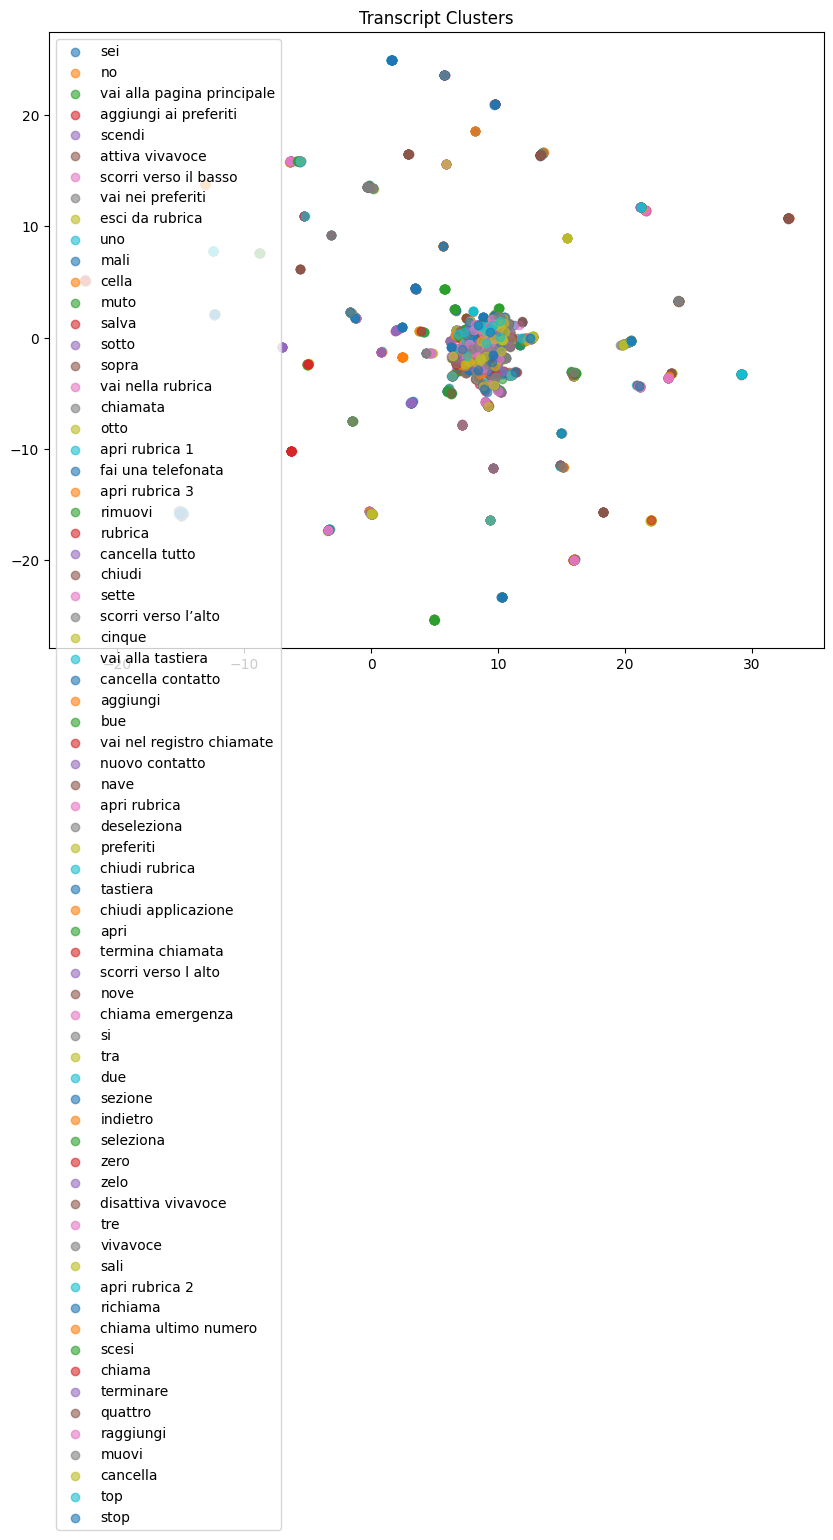

In [35]:
plt.figure(figsize=(10,8))

for cmd in set(labels):

    idx = [i for i,l in enumerate(labels) if l==cmd]

    plt.scatter(
        emb2d[idx,0],
        emb2d[idx,1],
        label=cmd,
        alpha=0.6
    )

plt.legend()
plt.title("Transcript Clusters")
plt.show()